# Predictive Model for Heart-related Issues
**Course:** CSC-180 Advanced Artificial Intelligence — Spring 2026  
**Group:** project(Alpha)  
**Members:** Wilson Luong, David Mcglasson, Brayan Mejia Nunez, Alejandro Oropeza, Hunter Powell, Moises Robledo

---
## Section 1: Imports & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from pandas.plotting import scatter_matrix
%pip install lightgbm catboost optuna -q

import sklearn
# this helps with numpy -> pandas transitions
sklearn.set_config(transform_output="pandas")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
from pathlib import Path
SAVE_DIR = Path.cwd() / "saved_model"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import urllib.request
import os

# List of potential raw GitHub mirrors for the dataset
urls = [
    "https://raw.githubusercontent.com/slmsshk/DataSet/main/heart_2020_cleaned.csv",
    "https://raw.githubusercontent.com/dileep-chinnareddy/Heart-Disease-Prediction/main/heart_2020_cleaned.csv",
    "https://media.githubusercontent.com/media/kamilpytlak/data-science-projects/main/heart_disease_prediction/dataset/heart_2020_cleaned.csv",
    "https://raw.githubusercontent.com/AndrawesAshraf/heart-2020-cleaned/main/heart_2020_cleaned.csv"
]

csv_path = "heart_2020_cleaned.csv"

# Try to download if it doesn't already exist
if not os.path.exists(csv_path):
    downloaded = False
    for url in urls:
        try:
            print(f"Trying to download from {url}...")
            urllib.request.urlretrieve(url, csv_path)
            downloaded = True
            print("Download successful!\n")
            break
        except Exception as e:
            print(f"Failed: {e}")

    # Fallback to kagglehub if github links fail
    if not downloaded:
        print("\nGitHub mirrors failed. Trying to use kagglehub...")
        try:
            import kagglehub
            # Download latest version
            path = kagglehub.dataset_download("andrawesashraffarouk/heart-2020-cleaned")
            csv_path = os.path.join(path, "heart_2020_cleaned.csv")
            print("Download successful via kagglehub! Path to dataset files:", path)
        except Exception as e:
            print(f"Kagglehub fallback failed: {e}. Please manually upload the CSV.")

# Load the dataset
try:
    dataset = pd.read_csv(csv_path, header=0)
    print(dataset.head(), "\n")   # 1st 5 rows
    print(dataset.tail(), "\n")   # last 5 rows
    print("Columns:", dataset.columns.tolist())
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")


Trying to download from https://raw.githubusercontent.com/slmsshk/DataSet/main/heart_2020_cleaned.csv...
Failed: HTTP Error 404: Not Found
Trying to download from https://raw.githubusercontent.com/dileep-chinnareddy/Heart-Disease-Prediction/main/heart_2020_cleaned.csv...
Failed: HTTP Error 404: Not Found
Trying to download from https://media.githubusercontent.com/media/kamilpytlak/data-science-projects/main/heart_disease_prediction/dataset/heart_2020_cleaned.csv...
Failed: HTTP Error 404: Not Found
Trying to download from https://raw.githubusercontent.com/AndrawesAshraf/heart-2020-cleaned/main/heart_2020_cleaned.csv...
Failed: HTTP Error 404: Not Found

GitHub mirrors failed. Trying to use kagglehub...


100%|██████████| 3.13M/3.13M [00:00<00:00, 199MB/s]

Extracting files...
Download successful via kagglehub! Path to dataset files: /root/.cache/kagglehub/datasets/andrawesashraffarouk/heart-2020-cleaned/versions/1


  HeartDisease    BMI Smoking AlcoholDrinking Stroke  PhysicalHealth  MentalHealth DiffWalking     Sex  AgeCategory   Race Diabetic PhysicalActivity  GenHealth  SleepTime Asthma KidneyDisease SkinCancer
0           No  16.60     Yes              No     No             3.0          30.0          No  Female        55-59  White      Yes              Yes  Very good        5.0    Yes            No        Yes
1           No  20.34      No              No    Yes             0.0           0.0          No  Female  80 or older  White       No              Yes  Very good        7.0     No            No         No
2           No  26.58     Yes              No     No            20.0          30.0          No    Male        65-69  White      Yes              Yes       Fair        8.0    Yes            No         No
3           No  24.21      No              No     No             0.0           0.0          No  Female        75-79  White       No               No       Good        6.0     No           

In [4]:
# preview dataset 2
# P1: check for missing values per feature
# P2: identify feature dtypes (numeric vs. object/categorical)
# P3: inspect target distribution for class imbalance
print(dataset.info(), "\n")
print(dataset.describe(), "\n")
print("Missing values per feature:\n", dataset.isnull().sum(), "\n")
print(dataset["HeartDisease"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

---
## Section 2: Data Preprocessing

### **We handle categorical/text encoding before checking for missing values because:**
*   This dataset contains no missing values (confirmed via `isnull().sum()` above), so encoding order does not introduce the label-assignment risk seen in datasets with nulls.
*   Binary Yes/No columns are mapped directly to {0, 1} to preserve their ordinal meaning without introducing magnitude bias that `LabelEncoder` might cause on multi-class columns.
*   Multi-category columns (AgeCategory, Race, GenHealth, Diabetic) are encoded using `OrdinalEncoder` with an explicit category order where meaningful, otherwise lexicographic.

In [5]:
# fix P1: Encode binary Yes/No columns -> {0, 1}
# direct map preserves semantic meaning and avoids LabelEncoder magnitude bias
binary_cols = [
    "HeartDisease", "Smoking", "AlcoholDrinking", "Stroke",
    "DiffWalking", "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"
]
yes_no_map = {"Yes": 1, "No": 0}
for col in binary_cols:
    dataset[col] = dataset[col].map(yes_no_map)

# sex: female -> 0, male -> 1
dataset["Sex"] = dataset["Sex"].map({"Female": 0, "Male": 1})

print("Binary encoding complete.")
print(dataset[binary_cols + ["Sex"]].head(), "\n")


Binary encoding complete.
   HeartDisease  Smoking  AlcoholDrinking  Stroke  DiffWalking  PhysicalActivity  Asthma  KidneyDisease  SkinCancer  Sex
0             0        1                0       0            0                 1       1              0           1    0
1             0        0                0       1            0                 1       0              0           0    0
2             0        1                0       0            0                 1       1              0           0    1
3             0        0                0       0            0                 0       0              0           1    0
4             0        0                0       0            1                 1       0              0           0    0 



In [6]:
# fix P2: Format multi-category columns for LightGBM/CatBoost native handling
# We REMOVED OrdinalEncoder. Tree models with native categorical support
# perform much better with pandas 'category' dtypes than mapped integers.

cat_cols = ["AgeCategory", "GenHealth", "Diabetic", "Race"]

for col in cat_cols:
    dataset[col] = dataset[col].astype('category')

print("Categorical formatting complete. Features converted to 'category' dtype.")
print(dataset.head(), "\n")
print(dataset.dtypes)

Categorical formatting complete. Features converted to 'category' dtype.
   HeartDisease    BMI  Smoking  AlcoholDrinking  Stroke  PhysicalHealth  MentalHealth  DiffWalking  Sex  AgeCategory   Race Diabetic  PhysicalActivity  GenHealth  SleepTime  Asthma  KidneyDisease  SkinCancer
0             0  16.60        1                0       0             3.0          30.0            0    0        55-59  White      Yes                 1  Very good        5.0       1              0           1
1             0  20.34        0                0       1             0.0           0.0            0    0  80 or older  White       No                 1  Very good        7.0       0              0           0
2             0  26.58        1                0       0            20.0          30.0            0    1        65-69  White      Yes                 1       Fair        8.0       1              0           0
3             0  24.21        0                0       0             0.0           0.0     

In [7]:
# fix P3: address class imbalance
# SMOTE removed to prevent data leakage!
# Applying SMOTE before the train/test split leaks test data into the training set.
# Instead, we will use class_weight='balanced' directly in our model (e.g., LightGBM).

print("Class distribution:")
print(dataset["HeartDisease"].value_counts(), "\n")
print("Dataset shape:", dataset.shape)


Class distribution:
HeartDisease
0    292422
1     27373
Name: count, dtype: int64 

Dataset shape: (319795, 18)


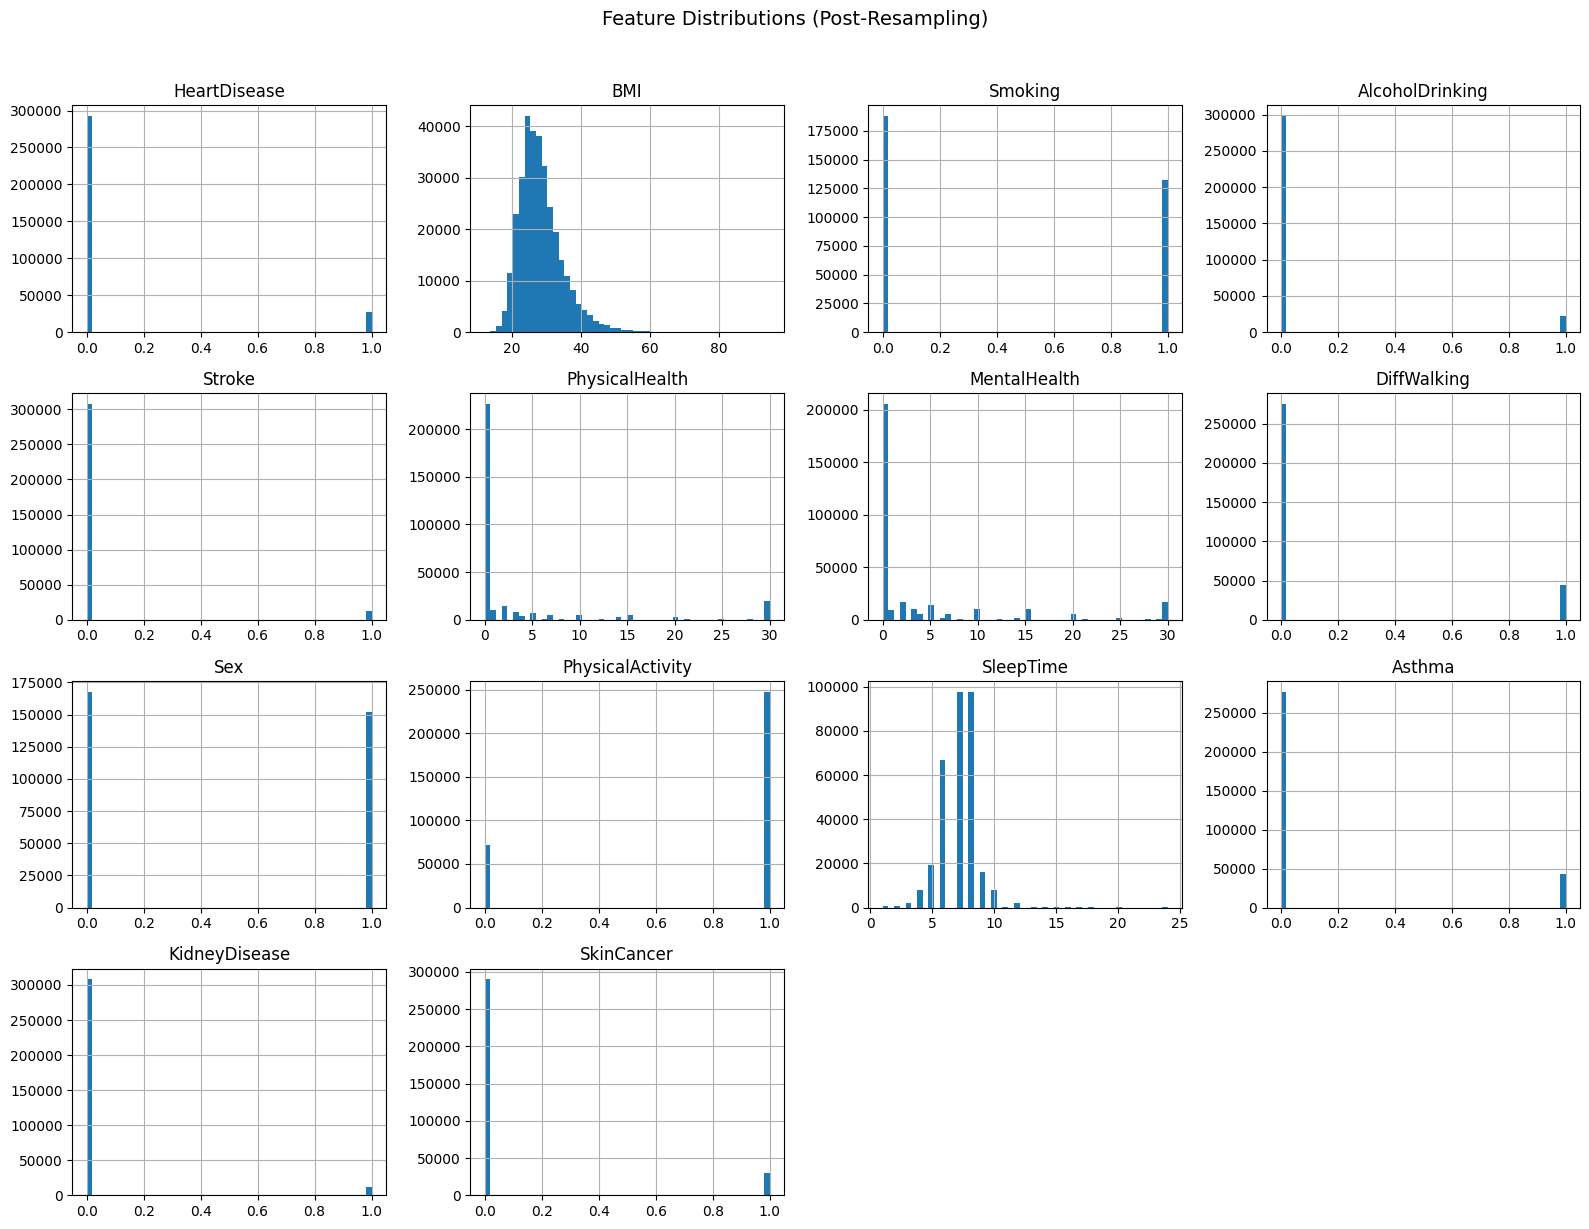

In [8]:
# graphical: preview dataset 1 - feature distributions
# histograms reveal skewness in numeric features (BMI, PhysicalHealth, MentalHealth, SleepTime)
# and show class balance after SMOTE resampling for HeartDisease
dataset.hist(bins=50, figsize=(16, 12))
plt.suptitle("Feature Distributions (Post-Resampling)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


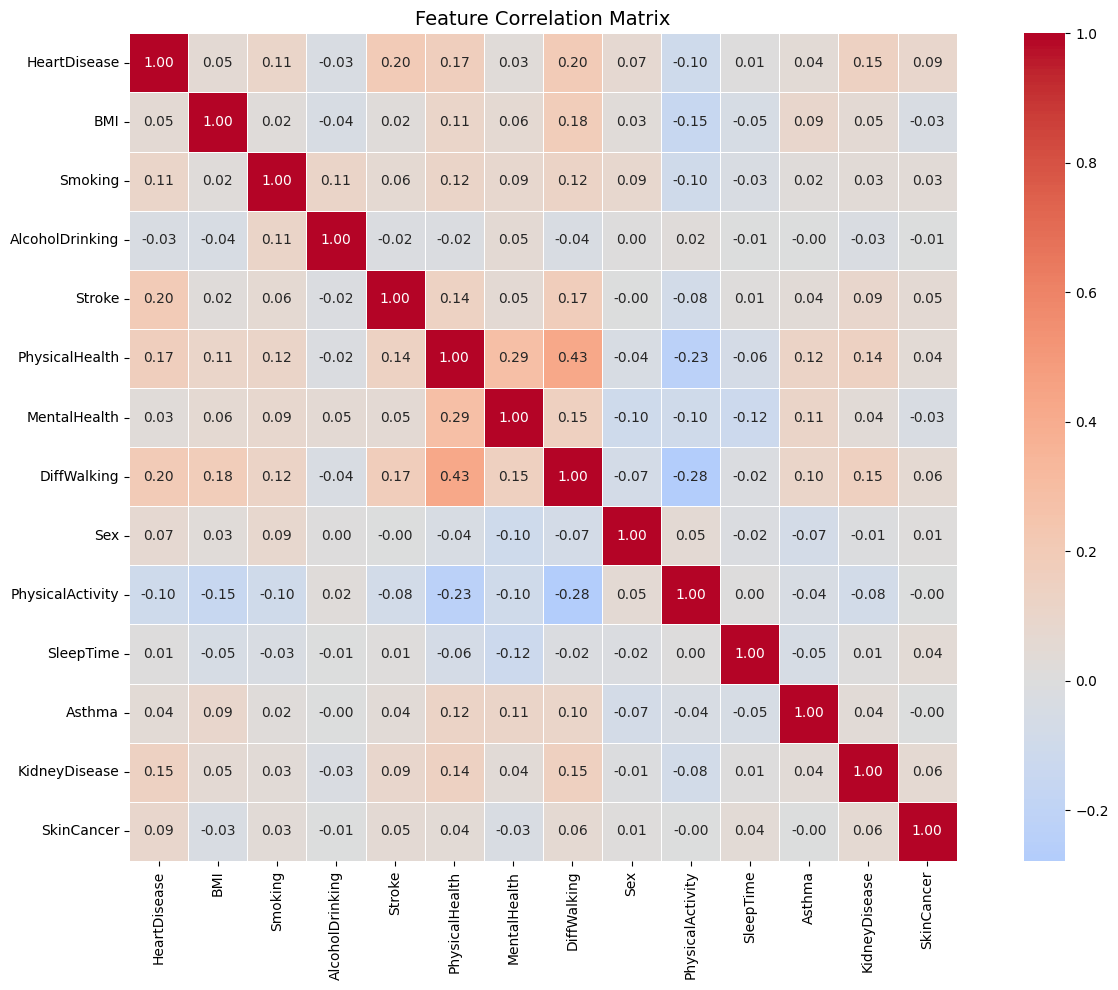

Correlation with HeartDisease (sorted):
DiffWalking         0.201258
Stroke              0.196835
PhysicalHealth      0.170721
KidneyDisease       0.145197
Smoking             0.107764
SkinCancer          0.093317
Sex                 0.070040
BMI                 0.051803
Asthma              0.041444
MentalHealth        0.028591
SleepTime           0.008327
AlcoholDrinking    -0.032080
PhysicalActivity   -0.100030
Name: HeartDisease, dtype: float64


In [9]:
# graphical: preview dataset 2 — correlation heatmap
# identifies features with high +/- correlation to HeartDisease (relevant/good features)
# and features near 0 correlation (potentially irrelevant/bad features for selection)
plt.figure(figsize=(14, 10))
corr_matrix = dataset.corr(numeric_only=True)
sbn.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# print correlation to target specifically
print("Correlation with HeartDisease (sorted):")
print(corr_matrix["HeartDisease"].drop("HeartDisease").sort_values(ascending=False))

In [10]:
# Feature Engineering -> Feature Identification
# separate independent features (X) from dependent target (y)

# 3. Clinically-Driven Feature Engineering
# Creating a risk score based on existing conditions
dataset["Comorbidity_Score"] = dataset["Stroke"] + dataset["Asthma"] + dataset["KidneyDisease"] + dataset["SkinCancer"]
dataset["health_burden"] = dataset["PhysicalHealth"] + dataset["MentalHealth"]
dataset["bmi_per_sleep"] = dataset["BMI"] / (dataset["SleepTime"] + 1e-6)
dataset["lifestyle_risk"] = dataset["Smoking"] + (1 - dataset["PhysicalActivity"])

feats_X = dataset.drop(columns=["HeartDisease"])
trgt_y  = pd.DataFrame(dataset["HeartDisease"])

print("Features (Inputs / Independent variables): ", feats_X.shape)
print("Target  (Output  / Dependent variable):   ", trgt_y.shape)
print("\nFeature columns:")
print(feats_X.columns.tolist())

Features (Inputs / Independent variables):  (319795, 21)
Target  (Output  / Dependent variable):    (319795, 1)

Feature columns:
['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer', 'Comorbidity_Score', 'health_burden', 'bmi_per_sleep', 'lifestyle_risk']


In [11]:
# 1. Map AgeCategory strings to numerical midpoints for valid mathematical interactions
age_map = {
    '18-24': 21, '25-29': 27, '30-34': 32, '35-39': 37, '40-44': 42,
    '45-49': 47, '50-54': 52, '55-59': 57, '60-64': 62, '65-69': 67,
    '70-74': 72, '75-79': 77, '80 or older': 82
}

# Create a temporary numeric age column for the interaction math
dataset["Age_Numeric"] = dataset["AgeCategory"].map(age_map).astype("float64")

# 2. Rebuild aggregate and interaction features (already partially done, adding age interaction)
dataset["health_burden"]     = dataset["PhysicalHealth"] + dataset["MentalHealth"]
dataset["bmi_per_sleep"]     = dataset["BMI"] / (dataset["SleepTime"] + 1e-6)

# Multiply the continuous health_burden by the numerical age, not the categorical string
dataset["age_health_burden"] = dataset["Age_Numeric"] * dataset["health_burden"]
dataset["lifestyle_risk"]    = dataset["Smoking"] + (1 - dataset["PhysicalActivity"])

# Update feats_X with the new features
feats_X = dataset.drop(columns=["HeartDisease"])

print("Updated Features shape: ", feats_X.shape)
print("\nUpdated Feature columns:")
print(feats_X.columns.tolist())


Updated Features shape:  (319795, 23)

Updated Feature columns:
['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer', 'Comorbidity_Score', 'health_burden', 'bmi_per_sleep', 'lifestyle_risk', 'Age_Numeric', 'age_health_burden']


In [12]:
# FIX: Train/Test Split WITHOUT Undersampling to prevent data loss!
# StratifiedShuffleSplit ensures both train and test sets contain proportional
# representation of each HeartDisease class (preserving the natural ~8.6% positive rate).
from sklearn.model_selection import StratifiedShuffleSplit

X = feats_X
y = trgt_y
print("X shape:", X.shape)
print("y shape:", y.shape, "\n")

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, train_size=0.8, random_state=42)
for train_idx, test_idx in strat_split.split(X, y):
    X_train_full, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test_full,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

print("Train class distribution (Full Dataset - Imbalanced):")
print(y_train.value_counts())

print("\nX_train_full:", X_train_full.shape, "\ty_train:", y_train.shape)
print("X_test_full: ", X_test_full.shape,  "\ty_test: ", y_test.shape)

print("\nTest class distribution (kept at natural ratio):")
print(y_test.value_counts())

X shape: (319795, 23)
y shape: (319795, 1) 

Train class distribution (Full Dataset - Imbalanced):
HeartDisease
0               233938
1                21898
Name: count, dtype: int64

X_train_full: (255836, 23) 	y_train: (255836, 1)
X_test_full:  (63959, 23) 	y_test:  (63959, 1)

Test class distribution (kept at natural ratio):
HeartDisease
0               58484
1                5475
Name: count, dtype: int64


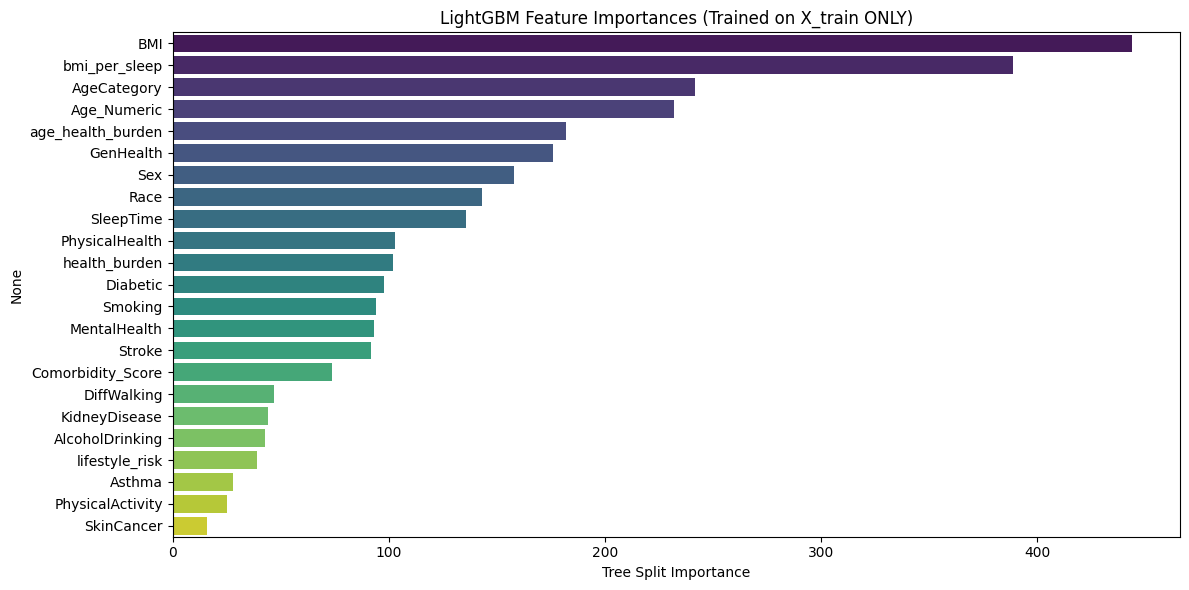


Selected features:
['BMI', 'PhysicalHealth', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'GenHealth', 'SleepTime', 'health_burden', 'bmi_per_sleep', 'Age_Numeric', 'age_health_burden']


In [13]:
# Feature Engineering -> Feature Selection via Tree-based Model
# FIT ON TRAINING DATA ONLY to prevent test-set data leakage.
from sklearn.feature_selection import SelectFromModel
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

# Use LightGBM to select features based on non-linear tree importance
selector_model = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, is_unbalance=True, verbose=-1)
# We'll select features whose importance is greater than or equal to the median importance
selector = SelectFromModel(selector_model, prefit=False, max_features=12, threshold="median")

# Fit on Train, Transform both Train and Test
X_train_selected = selector.fit_transform(X_train_full, y_train.values.ravel())
X_test_selected  = selector.transform(X_test_full)

useful_features = selector.get_feature_names_out(X_train_full.columns)
X_train = pd.DataFrame(X_train_selected, columns=useful_features)
X_test  = pd.DataFrame(X_test_selected,  columns=useful_features)

# visualize feature importances for interpretability
selector_model.fit(X_train_full, y_train.values.ravel())
feat_scores = pd.Series(selector_model.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sbn.barplot(x=feat_scores.values, y=feat_scores.index, hue=feat_scores.index, palette="viridis", legend=False)
plt.title("LightGBM Feature Importances (Trained on X_train ONLY)")
plt.xlabel("Tree Split Importance")
plt.tight_layout()
plt.show()

print("\nSelected features:")
print(X_train.columns.tolist())

In [14]:
# fix P4: Feature Transformation
# do not require feature scaling and are invariant to monotonic transformations.
# We simply pass the data through to keep the pipeline intact.

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# flatten y to 1D array for sklearn compatibility
y_train_arr = y_train.values.ravel()
y_test_arr  = y_test.values.ravel()

print("Transformation skipped (Tree-models do not require it).")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)

Transformation skipped (Tree-models do not require it).
X_train_scaled shape: (255836, 12)
X_test_scaled shape:  (63959, 12)


In [15]:
# select ML algorithm and configure hyperparameters
# six models evaluated: KNN, Logistic Regression, Random Forest, XGBoost, Naive Bayes, MLP
# switch ml_algorithm string to change active model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

ml_algorithm = "LightGBM"            # best performer in testing

if ml_algorithm == "KNN":
    algorithm = KNeighborsClassifier(n_neighbors=7, metric='minkowski', weights='distance')

elif ml_algorithm == "LogisticRegression":
    algorithm = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)

elif ml_algorithm == "RandomForest":
    algorithm = RandomForestClassifier(n_estimators=1000, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)

elif ml_algorithm == "XGBoost":
    algorithm = XGBClassifier(
        n_estimators=1000, max_depth=6, learning_rate=0.1,
        scale_pos_weight=10.7, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )

elif ml_algorithm == "NaiveBayes":
    algorithm = GaussianNB()

elif ml_algorithm == "MLP":
    algorithm = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu',
        solver='adam', max_iter=100, early_stopping=True,
        validation_fraction=0.1, batch_size=512,
        random_state=42
    )

# seemingly top performer
elif ml_algorithm == "LightGBM":
    algorithm = LGBMClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.0108,
        num_leaves=104,
        subsample=0.7717,
        colsample_bytree=0.5940,
        min_child_samples=50,
        scale_pos_weight=10.7, # Added to handle natural 10:1 data imbalance safely natively, eliminates need for SMOTE/undersampling
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

elif ml_algorithm == "CatBoost":
    algorithm = CatBoostClassifier(
        iterations=500, depth=7, learning_rate=0.05,
        auto_class_weights='Balanced',
        random_state=42, verbose=0
    )

else:
    raise ValueError(f"Unknown algorithm: {ml_algorithm}")

print(f"Active model: {ml_algorithm}")
print(algorithm)

Active model: LightGBM
LGBMClassifier(colsample_bytree=0.594, learning_rate=0.0108, max_depth=5,
               min_child_samples=50, n_estimators=500, n_jobs=-1,
               num_leaves=104, random_state=42, scale_pos_weight=10.7,
               subsample=0.7717, verbose=-1)


=== TRAINING Performance (LightGBM) — 5-Fold CV ===
Accuracy:  0.7197
Precision: 0.9093
Recall:    0.7197
F1-Score:  0.7806
AUC:       0.8321
MCC:       0.3071


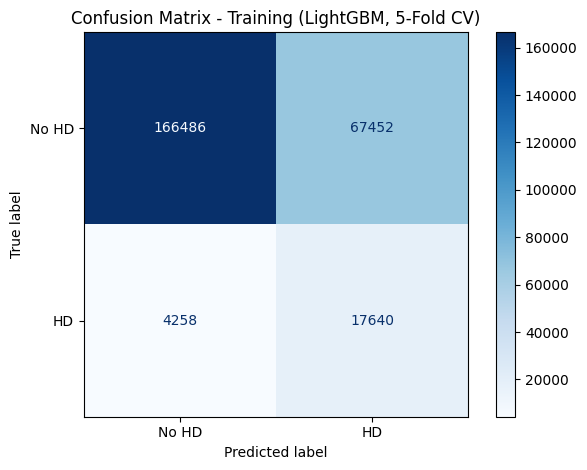

In [16]:
# TRAINING: K-Fold Cross-Validation (k=5)
# cross_val_predict generates out-of-fold predictions for the full training set,
# giving an unbiased estimate of training performance before out-of-sample testing.
# overfitting:  Train ERR << Test ERR
# underfitting: Train ERR >> Test ERR (or both ERR high)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    ConfusionMatrixDisplay
)

# Get binary predictions for standard metrics
cv_preds = cross_val_predict(algorithm, X_train_scaled, y_train_arr, cv=5, n_jobs=1)
# Get probabilities specifically for AUC
cv_proba = cross_val_predict(algorithm, X_train_scaled, y_train_arr, cv=5, method='predict_proba', n_jobs=1)

# evaluate training performance
acc_train   = accuracy_score(y_train_arr, cv_preds)
pr_rc_fs    = precision_recall_fscore_support(y_train_arr, cv_preds, average='weighted')
mcc_train   = matthews_corrcoef(y_train_arr, cv_preds)

# FIX: calculate AUC using probabilities, not binary predictions
auc_train   = roc_auc_score(y_train_arr, cv_proba[:, 1])

print(f"=== TRAINING Performance ({ml_algorithm}) — 5-Fold CV ===")
print(f"Accuracy:  {acc_train:.4f}")
print(f"Precision: {pr_rc_fs[0]:.4f}")
print(f"Recall:    {pr_rc_fs[1]:.4f}")
print(f"F1-Score:  {pr_rc_fs[2]:.4f}")
print(f"AUC:       {auc_train:.4f}")
print(f"MCC:       {mcc_train:.4f}")

# confusion matrix — training
cm_train = confusion_matrix(y_train_arr, cv_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["No HD", "HD"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Training ({ml_algorithm}, 5-Fold CV)")
plt.tight_layout()
plt.show()


=== TEST Performance (LightGBM) — Out-of-Sample (Threshold: 0.5917) ===
Accuracy:  0.7784
Precision: 0.9048
Recall:    0.7784
F1-Score:  0.8225
AUC:       0.8293
MCC:       0.3201


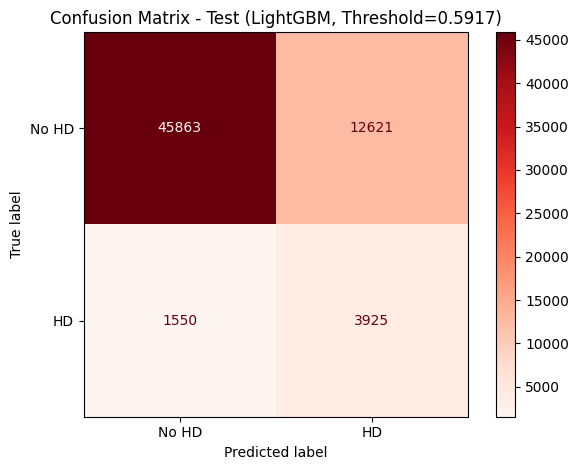

In [17]:
# TESTING/GENERALIZATION: fit final model on full training set, predict on held-out test set
# compare Train vs. Test metrics to diagnose overfitting/underfitting:
# overfitting:  Train metrics >> Test metrics
# underfitting: Both Train and Test metrics are low
model = algorithm
model.fit(X_train_scaled, y_train_arr)

# --- CUSTOM THRESHOLD ADJUSTMENT ---
# Default is 0.5.
# Lower = catches more HD cases (higher recall, lower precision).
# Higher = more strict/confident before predicting HD (higher precision, lower recall).
CUSTOM_THRESHOLD = 0.5917

# Get probabilities for the positive class (HeartDisease=1)
proba_y_test = model.predict_proba(X_test_scaled)[:, 1]

# Apply the custom threshold to get binary predictions (0 or 1)
import numpy as np
pred_y_test = (proba_y_test >= CUSTOM_THRESHOLD).astype(int)

acc_test  = accuracy_score(y_test_arr, pred_y_test)
pr_rc_fs_test = precision_recall_fscore_support(y_test_arr, pred_y_test, average='weighted')
mcc_test  = matthews_corrcoef(y_test_arr, pred_y_test)

# FIX: calculate AUC using probabilities, not binary predictions
auc_test  = roc_auc_score(y_test_arr, proba_y_test)

print(f"=== TEST Performance ({ml_algorithm}) — Out-of-Sample (Threshold: {CUSTOM_THRESHOLD}) ===")
print(f"Accuracy:  {acc_test:.4f}")
print(f"Precision: {pr_rc_fs_test[0]:.4f}")
print(f"Recall:    {pr_rc_fs_test[1]:.4f}")
print(f"F1-Score:  {pr_rc_fs_test[2]:.4f}")
print(f"AUC:       {auc_test:.4f}")
print(f"MCC:       {mcc_test:.4f}")

# confusion matrix - test
cm_test = confusion_matrix(y_test_arr, pred_y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No HD", "HD"])
disp.plot(cmap='Reds')
plt.title(f"Confusion Matrix - Test ({ml_algorithm}, Threshold={CUSTOM_THRESHOLD})")
plt.tight_layout()
plt.show()



=== LightGBM — Train vs. Test Summary ===
   Metric  Train (CV)   Test
 Accuracy      0.7197 0.7784
Precision      0.9093 0.9048
   Recall      0.7197 0.7784
 F1-Score      0.7806 0.8225
      AUC      0.8321 0.8293
      MCC      0.3071 0.3201


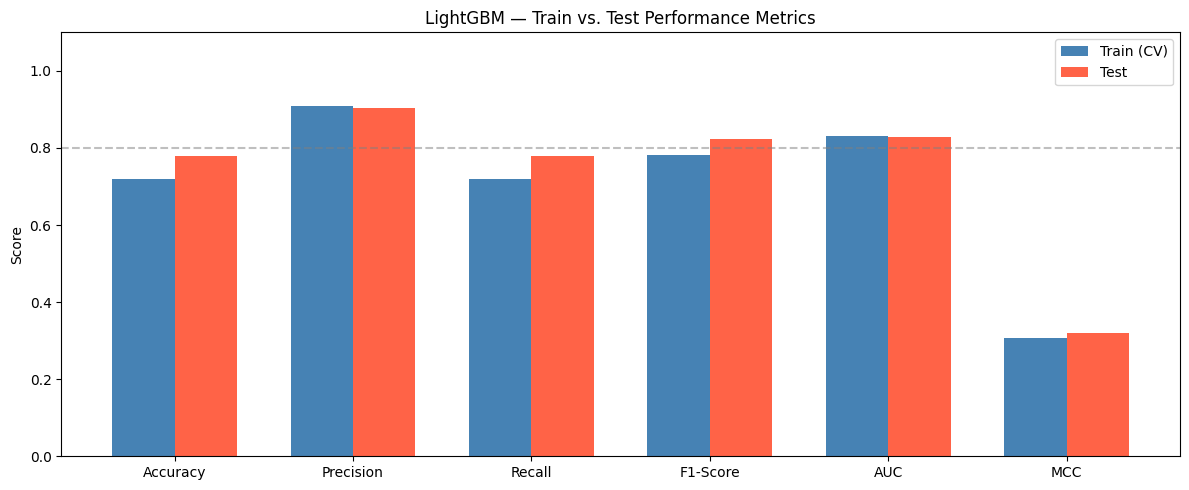

In [18]:
# performance Summary: Train vs. Test comparison
# side-by-side table makes overfitting/underfitting immediately visible
summary = pd.DataFrame({
    "Metric":    ["Accuracy", "Precision", "Recall", "F1-Score", "AUC", "MCC"],
    "Train (CV)": [
        round(acc_train, 4),
        round(pr_rc_fs[0], 4),
        round(pr_rc_fs[1], 4),
        round(pr_rc_fs[2], 4),
        round(auc_train, 4),
        round(mcc_train, 4)
    ],
    "Test": [
        round(acc_test, 4),
        round(pr_rc_fs_test[0], 4),
        round(pr_rc_fs_test[1], 4),
        round(pr_rc_fs_test[2], 4),
        round(auc_test, 4),
        round(mcc_test, 4)
    ]
})
print(f"\n=== {ml_algorithm} — Train vs. Test Summary ===")
print(summary.to_string(index=False))

# visual comparison
x = range(len(summary))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], summary["Train (CV)"], width, label="Train (CV)", color="steelblue")
ax.bar([i + width/2 for i in x], summary["Test"],       width, label="Test",       color="tomato")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["Metric"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title(f"{ml_algorithm} — Train vs. Test Performance Metrics")
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 reference')
plt.tight_layout()
plt.show()


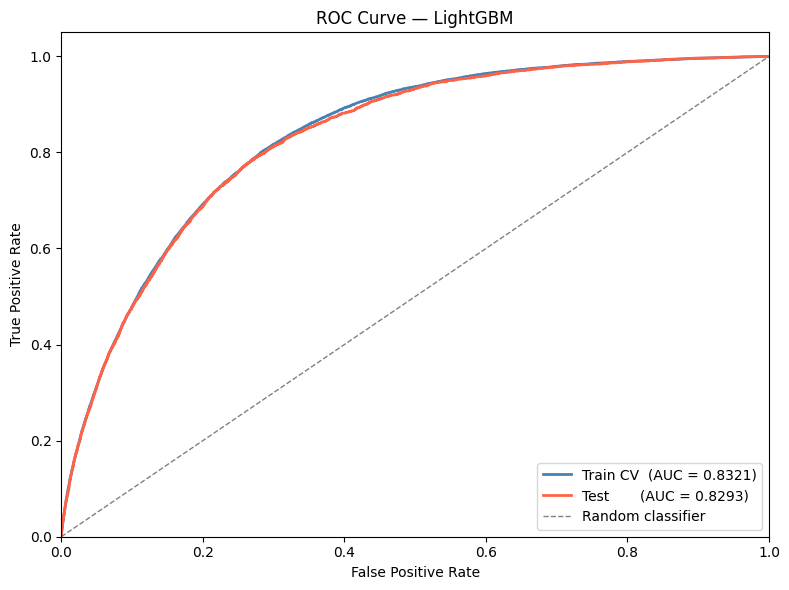

Train CV AUC: 0.8321
Test     AUC: 0.8293


In [19]:
# ROC Curve — Train (CV) vs. Test
# uses predict_proba to get probability scores for the positive class (HeartDisease=1)
# AUC closer to 1.0 = better discrimination; diagonal = random classifier baseline
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict

# Changed cv=3 and n_jobs=1 to prevent thread oversubscription with LightGBM
# out-of-fold probabilities on training set (unbiased CV estimate)
cv_proba = cross_val_predict(model, X_train_scaled, y_train_arr, cv=3, method='predict_proba', n_jobs=1)
fpr_train, tpr_train, _ = roc_curve(y_train_arr, cv_proba[:, 1])
auc_train_roc = auc(fpr_train, tpr_train)

# test set probabilities
test_proba = model.predict_proba(X_test_scaled)
fpr_test, tpr_test, _ = roc_curve(y_test_arr, test_proba[:, 1])
auc_test_roc = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='steelblue', lw=2,
         label=f"Train CV  (AUC = {auc_train_roc:.4f})")
plt.plot(fpr_test,  tpr_test,  color='tomato',    lw=2,
         label=f"Test       (AUC = {auc_test_roc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {ml_algorithm}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Train CV AUC: {auc_train_roc:.4f}")
print(f"Test     AUC: {auc_test_roc:.4f}")


In [23]:
import joblib

model = algorithm
joblib.dump(selector, SAVE_DIR / "selector.pkl")
joblib.dump(model,    SAVE_DIR / "model.pkl")
print("Saved to:", SAVE_DIR)

Saved to: /content/saved_model


In [24]:
import joblib, numpy as np, pandas as pd, os



selector_loaded = joblib.load(f"{SAVE_DIR}/selector.pkl")
model_loaded    = joblib.load(f"{SAVE_DIR}/model.pkl")

# ── YOUR INPUTS ────────────────────────────────────────────────────────────────
BMI             = 24.0
Smoking         = "No"          # "Yes" / "No"
AlcoholDrinking = "No"          # "Yes" / "No"
Stroke          = "No"          # "Yes" / "No"
PhysicalHealth  = 0.0           # days of poor physical health in past 30 days (0–30)
MentalHealth    = 0.0           # days of poor mental health in past 30 days (0–30)
DiffWalking     = "No"          # "Yes" / "No"
Sex             = "Male"        # "Male" / "Female"
AgeCategory     = "25-29"       # "18-24","25-29","30-34","35-39","40-44","45-49",
                                #  "50-54","55-59","60-64","65-69","70-74","75-79","80 or older"
Race            = "White"       # "White","Black","Hispanic","Asian",
                                #  "American Indian/Alaskan Native","Other"
Diabetic        = "No"          # "No","No, borderline diabetes","Yes (during pregnancy)","Yes"
PhysicalActivity = "Yes"        # "Yes" / "No"
GenHealth       = "Very good"   # "Poor","Fair","Good","Very good","Excellent"
SleepTime       = 7.0           # hours of sleep per night (1–24)
Asthma          = "No"          # "Yes" / "No"
KidneyDisease   = "No"          # "Yes" / "No"
SkinCancer      = "No"          # "Yes" / "No"
# ──────────────────────────────────────────────────────────────────────────────

yes_no = {"Yes": 1, "No": 0}
row = {
    "BMI":             BMI,
    "Smoking":         yes_no[Smoking],
    "AlcoholDrinking": yes_no[AlcoholDrinking],
    "Stroke":          yes_no[Stroke],
    "PhysicalHealth":  PhysicalHealth,
    "MentalHealth":    MentalHealth,
    "DiffWalking":     yes_no[DiffWalking],
    "Sex":             1 if Sex == "Male" else 0,
    "AgeCategory":     AgeCategory,
    "Race":            Race,
    "Diabetic":        Diabetic,
    "PhysicalActivity": yes_no[PhysicalActivity],
    "GenHealth":       GenHealth,
    "SleepTime":       SleepTime,
    "Asthma":          yes_no[Asthma],
    "KidneyDisease":   yes_no[KidneyDisease],
    "SkinCancer":      yes_no[SkinCancer],
}
df = pd.DataFrame([row])

# Convert categorical columns to pandas 'category' dtype as expected by LightGBM
cat_cols = ["AgeCategory", "GenHealth", "Diabetic", "Race"]
for col in cat_cols:
    # We need to ensure they have the same categories as the training set
    df[col] = pd.Categorical(df[col], categories=dataset[col].cat.categories)

# Feature Engineering (must match training exactly)
# Map AgeCategory to numeric for interaction features
age_map = {
    '18-24': 21, '25-29': 27, '30-34': 32, '35-39': 37, '40-44': 42,
    '45-49': 47, '50-54': 52, '55-59': 57, '60-64': 62, '65-69': 67,
    '70-74': 72, '75-79': 77, '80 or older': 82
}
df["Age_Numeric"] = df["AgeCategory"].map(age_map).astype("float64")

df["Comorbidity_Score"] = df["Stroke"] + df["Asthma"] + df["KidneyDisease"] + df["SkinCancer"]
df["health_burden"]     = df["PhysicalHealth"] + df["MentalHealth"]
df["bmi_per_sleep"]     = df["BMI"] / (df["SleepTime"] + 1e-6)
df["age_health_burden"] = df["Age_Numeric"] * df["health_burden"]
df["lifestyle_risk"]    = df["Smoking"] + (1 - df["PhysicalActivity"])

# Ensure columns are in the exact same order as training data before selection
# feats_X was the dataframe before selector
for col in feats_X.columns:
    if col not in df.columns:
        df[col] = 0 # Fallback in case of missing columns, though our row has all of them
df = df[feats_X.columns]

# Apply the tree-based feature selector
X_selected = selector_loaded.transform(df)

# Predict using the loaded model
pred     = model_loaded.predict(X_selected)[0]
proba    = model_loaded.predict_proba(X_selected)[0]

print(f"\nPrediction : {'⚠ Heart Disease' if pred == 1 else '✓ No Heart Disease'}")
print(f"Confidence : No HD = {proba[0]:.1%}  |  HD = {proba[1]:.1%}")


Prediction : ✓ No Heart Disease
Confidence : No HD = 95.6%  |  HD = 4.4%


---
## Model Comparison
Evaluating the optimized LightGBM against other popular algorithms (Logistic Regression, Random Forest, XGBoost, CatBoost) on the exact same test set.

Training and evaluating models ...
Processing LightGBM (Optimized)...
Processing Logistic Regression...
Processing Random Forest...
Processing XGBoost...
Processing CatBoost...

 Model Comparison Results 


,Model,Accuracy,Precision,Recall,F1-Score,AUC,MCC
0,LightGBM (Optimized),0.7174,0.9089,0.7174,0.7789,0.8293,0.3040
1,Logistic Regression,0.7318,0.9069,0.7318,0.7894,0.8233,0.3035
2,Random Forest,0.7206,0.9079,0.7206,0.7812,0.8250,0.3018
3,XGBoost,0.7247,0.9079,0.7247,0.7842,0.8281,0.3039
4,CatBoost,0.7189,0.9086,0.7189,0.7799,0.8285,0.3037


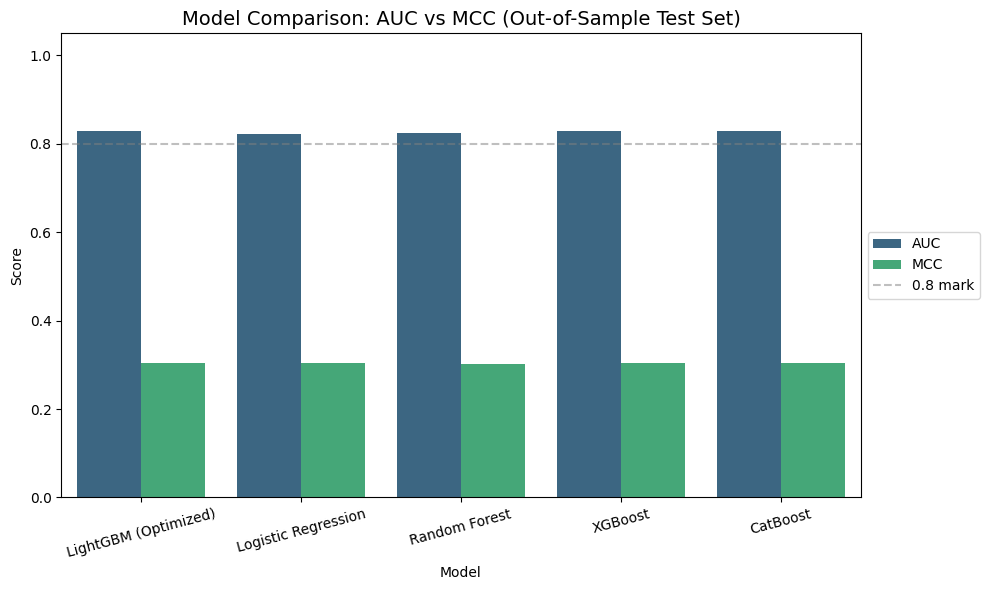

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, matthews_corrcoef
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Identify categorical columns
cat_features = X_train_scaled.select_dtypes(include=['category', 'object']).columns.tolist()

# Define models with appropriate class imbalance handling
models_to_compare = {
    "LightGBM (Optimized)": model, # Our already trained and tuned model
    "Logistic Regression": LogisticRegression(C=0.005563622121093846, class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=17, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(learning_rate=0.04502624539642165, scale_pos_weight=10.7, n_estimators=100, max_depth=7, random_state=42, n_jobs=-1, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(learning_rate=0.025023553784899275, iterations=250, depth=6, auto_class_weights='Balanced', random_state=42, verbose=0, cat_features=cat_features)
}

# Create one-hot encoded datasets for models that need purely numeric inputs
X_train_enc = pd.get_dummies(X_train_scaled, columns=cat_features, drop_first=True, dtype=float)
X_test_enc  = pd.get_dummies(X_test_scaled, columns=cat_features, drop_first=True, dtype=float)
# Ensure columns align perfectly
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0.0)

results = []

print("Training and evaluating models ...")
for name, clf in models_to_compare.items():
    print(f"Processing {name}...")

    # Select the correct dataset based on model capability
    if name in ["LightGBM (Optimized)", "CatBoost"]:
        X_train_curr = X_train_scaled
        X_test_curr  = X_test_scaled
    else:
        X_train_curr = X_train_enc
        X_test_curr  = X_test_enc

    # Skip training for LightGBM since it's already trained
    if name != "LightGBM (Optimized)":
        clf.fit(X_train_curr, y_train_arr)

    # Predict on Test Set
    proba = clf.predict_proba(X_test_curr)[:, 1]
    preds = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test_arr, preds)
    pr, rc, fs, _ = precision_recall_fscore_support(y_test_arr, preds, average='weighted')
    auc = roc_auc_score(y_test_arr, proba)
    mcc = matthews_corrcoef(y_test_arr, preds)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pr,
        "Recall": rc,
        "F1-Score": fs,
        "AUC": auc,
        "MCC": mcc
    })

# Create DataFrame and display
comparison_df = pd.DataFrame(results)
print("\n Model Comparison Results ")
display(comparison_df.round(4))

# Plot AUC and MCC comparison
comparison_df_melted = comparison_df.melt(id_vars="Model", value_vars=["AUC", "MCC"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sbn.barplot(data=comparison_df_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model Comparison: AUC vs MCC (Out-of-Sample Test Set)", fontsize=14)
plt.ylim(0, 1.05)
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 mark')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Heart Disease Risk Predictor — Gradio Demo

%pip install gradio -q

import gradio as gr
import pandas as pd
import joblib
import os

print("Loading saved model and selector...")
selector = joblib.load(SAVE_DIR / "selector.pkl")
model = joblib.load(SAVE_DIR / "model.pkl")


# option lists
yes_no_opts    = ["No", "Yes"]
sex_opts       = ["Female", "Male"]
age_opts       = ['18-24','25-29','30-34','35-39','40-44','45-49',
                  '50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
race_opts      = ['American Indian/Alaskan Native','Asian','Black',
                  'Hispanic','Other','White']
diabetic_opts  = ['No','No, borderline diabetes','Yes','Yes (during pregnancy)']
genhealth_opts = ['Excellent','Very good','Good','Fair','Poor']

# Original Categories required for the pandas 'category' type
cat_categories = {
    "AgeCategory": age_opts,
    "Race": race_opts,
    "Diabetic": diabetic_opts,
    "GenHealth": ['Excellent', 'Fair', 'Good', 'Poor', 'Very good']
}

age_map = {
    '18-24': 21, '25-29': 27, '30-34': 32, '35-39': 37, '40-44': 42,
    '45-49': 47, '50-54': 52, '55-59': 57, '60-64': 62, '65-69': 67,
    '70-74': 72, '75-79': 77, '80 or older': 82
}

PRESET_KEYS = ["BMI","Smoking","AlcoholDrinking","Stroke","PhysicalHealth",
               "MentalHealth","DiffWalking","Sex","AgeCategory","Race","Diabetic",
               "PhysicalActivity","GenHealth","SleepTime","Asthma","KidneyDisease",
               "SkinCancer"]

# Expected features before selection
expected_columns = [
    'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth',
    'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
    'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer',
    'Comorbidity_Score', 'health_burden', 'bmi_per_sleep', 'lifestyle_risk',
    'Age_Numeric', 'age_health_burden'
]

PRESETS = {

    "Custom": None,

    "Healthy young adult": dict(
        BMI=22.5, Smoking="No", AlcoholDrinking="No", Stroke="No",
        PhysicalHealth=0, MentalHealth=0, DiffWalking="No", Sex="Female",
        AgeCategory="25-29", Race="White", Diabetic="No",
        PhysicalActivity="Yes", GenHealth="Excellent", SleepTime=8.0,
        Asthma="No", KidneyDisease="No", SkinCancer="No"),

    "High-risk older adult": dict(
        BMI=33.0, Smoking="Yes", AlcoholDrinking="No", Stroke="Yes",
        PhysicalHealth=20, MentalHealth=10, DiffWalking="Yes", Sex="Male",
        AgeCategory="70-74", Race="White", Diabetic="Yes",
        PhysicalActivity="No", GenHealth="Poor", SleepTime=5.0,
        Asthma="Yes", KidneyDisease="Yes", SkinCancer="No"),

    "Borderline middle-aged": dict(
        BMI=29.0, Smoking="Yes", AlcoholDrinking="No", Stroke="No",
        PhysicalHealth=5, MentalHealth=3, DiffWalking="No", Sex="Male",
        AgeCategory="55-59", Race="Hispanic",
        Diabetic="No, borderline diabetes", PhysicalActivity="No",
        GenHealth="Fair", SleepTime=6.0, Asthma="No",
        KidneyDisease="No", SkinCancer="No"),
}

def predict_fn(BMI, Smoking, AlcoholDrinking, Stroke, PhysicalHealth, MentalHealth,
               DiffWalking, Sex, AgeCategory, Race, Diabetic, PhysicalActivity,
               GenHealth, SleepTime, Asthma, KidneyDisease, SkinCancer, threshold):
    try:
        yn  = {"Yes": 1, "No": 0}
        row = {
            "BMI":              BMI,
            "Smoking":          yn[Smoking],
            "AlcoholDrinking":  yn[AlcoholDrinking],
            "Stroke":           yn[Stroke],
            "PhysicalHealth":   float(PhysicalHealth),
            "MentalHealth":     float(MentalHealth),
            "DiffWalking":      yn[DiffWalking],
            "Sex":              1 if Sex == "Male" else 0,
            "AgeCategory":      AgeCategory,
            "Race":             Race,
            "Diabetic":         Diabetic,
            "PhysicalActivity": yn[PhysicalActivity],
            "GenHealth":        GenHealth,
            "SleepTime":        float(SleepTime),
            "Asthma":           yn[Asthma],
            "KidneyDisease":    yn[KidneyDisease],
            "SkinCancer":       yn[SkinCancer],
        }
        df = pd.DataFrame([row])

        for col in ["AgeCategory", "GenHealth", "Diabetic", "Race"]:
            df[col] = pd.Categorical(df[col], categories=cat_categories.get(col, df[col].unique()))

        df["Age_Numeric"]       = df["AgeCategory"].map(age_map).astype("float64")
        df["Comorbidity_Score"] = df["Stroke"] + df["Asthma"] + df["KidneyDisease"] + df["SkinCancer"]
        df["health_burden"]     = df["PhysicalHealth"] + df["MentalHealth"]
        df["bmi_per_sleep"]     = df["BMI"] / (df["SleepTime"] + 1e-6)
        df["age_health_burden"] = df["Age_Numeric"] * df["health_burden"]
        df["lifestyle_risk"]    = df["Smoking"] + (1 - df["PhysicalActivity"])

        for col in expected_columns:
            if col not in df.columns:
                df[col] = 0
        df = df[expected_columns]

        selected_cols = selector.get_feature_names_out(expected_columns)
        X_sel = df[selected_cols]

        proba_hd = float(model.predict_proba(X_sel)[0, 1])
        pred     = int(proba_hd >= threshold)

        if pred == 1:
            accent   = "#7d2d2d"
            verdict  = "Elevated risk"
            category = "The model predicts heart disease for this profile."
        else:
            accent   = "#2d5f3f"
            verdict  = "Low risk"
            category = "The model does not predict heart disease for this profile."

        bar_pct = max(0.5, proba_hd * 100)
        thr_pct = threshold * 100

        return f"""
        <div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Inter,sans-serif;
                    background:#ffffff;border:1px solid #d6d3cd;
                    border-left:4px solid {accent};padding:24px 28px;border-radius:2px;">
          <div style="font-size:10px;letter-spacing:0.18em;text-transform:uppercase;
                      color:#7a7368;font-weight:700;">Prediction</div>
          <div style="font-family:Georgia,'Times New Roman',serif;font-size:28px;
                      font-weight:600;color:{accent};margin-top:4px;
                      letter-spacing:-0.015em;line-height:1.2;">{verdict}</div>
          <div style="font-size:14px;color:#4a463e;margin-top:6px;">{category}</div>
          <div style="margin-top:24px;">
            <div style="display:flex;justify-content:space-between;align-items:baseline;
                        font-size:12px;color:#6e675b;margin-bottom:8px;">
              <span style="letter-spacing:0.04em;">Probability of heart disease</span>
              <span style="font-weight:600;color:#1a1a2e;font-variant-numeric:tabular-nums;
                           font-size:13px;">{proba_hd:.3f}</span>
            </div>
            <div style="position:relative;width:100%;height:8px;background:#ece9e2;
                        border-radius:1px;">
              <div style="width:{bar_pct}%;height:100%;background:{accent};
                          border-radius:1px;"></div>
              <div style="position:absolute;top:-5px;left:calc({thr_pct}% - 1px);
                          width:2px;height:18px;background:#1a1a2e;"></div>
            </div>
            <div style="display:flex;justify-content:space-between;font-size:11px;
                        color:#8a8378;margin-top:8px;font-variant-numeric:tabular-nums;">
              <span>0.000</span>
              <span>Decision threshold {threshold:.3f}</span>
              <span>1.000</span>
            </div>
          </div>
        </div>
        """
    except Exception as e:
        return (f"<div style='color:#7d2d2d;font-family:system-ui;padding:16px;'>"
                f"Prediction failed: {e!r}</div>")


def apply_preset(preset_name, *current_values):
    p = PRESETS.get(preset_name)
    if p is None:
        return list(current_values)
    return [p[k] for k in PRESET_KEYS]


CUSTOM_CSS = """
.gradio-container { max-width: 1080px !important; }
footer { visibility: hidden; }

.app-header {
    border-bottom: 2px solid #1e3a5f;
    padding: 4px 0 18px 0;
    margin-bottom: 8px;
}
.app-eyebrow {
    font-size: 11px;
    letter-spacing: 0.18em;
    text-transform: uppercase;
    color: #6e675b;
    font-weight: 600;
    font-family: -apple-system, BlinkMacSystemFont, system-ui, sans-serif;
}
.app-title {
    font-family: Georgia, 'Times New Roman', serif;
    font-size: 32px;
    font-weight: 600;
    color: #d6d3cd;
    margin: 6px 0 0 0;
    letter-spacing: -0.015em;
    line-height: 1.15;
}
.app-byline {
    font-size: 13px;
    color: #4a463e;
    margin-top: 8px;
    font-family: -apple-system, BlinkMacSystemFont, system-ui, sans-serif;
    line-height: 1.5;
}
.app-disclaimer {
    font-size: 12px;
    color: #6e675b;
    margin-top: 14px;
    padding: 10px 14px;
    background: #f5f2eb;
    border-left: 3px solid #c4bdb0;
    font-family: -apple-system, BlinkMacSystemFont, system-ui, sans-serif;
    line-height: 1.5;
}
.section-header {
    font-size: 11px;
    font-weight: 700;
    letter-spacing: 0.14em;
    text-transform: uppercase;
    color: #1e3a5f;
    border-bottom: 1px solid #d6d3cd;
    padding-bottom: 8px;
    margin: 16px 0 4px 0;
    font-family: -apple-system, BlinkMacSystemFont, system-ui, sans-serif;
}
"""

theme = gr.themes.Default(
    primary_hue=gr.themes.colors.slate,
    neutral_hue=gr.themes.colors.stone,
    font=[gr.themes.GoogleFont("Inter"), "system-ui", "sans-serif"],
).set(
    body_background_fill="#fbfaf7",
    block_background_fill="#ffffff",
    block_border_color="#d6d3cd",
    block_border_width="1px",
    block_label_text_color="#4a463e",
    block_label_text_size="12px",
    block_label_text_weight="500",
    button_primary_background_fill="#1e3a5f",
    button_primary_background_fill_hover="#2a4a73",
    button_primary_text_color="#ffffff",
    button_primary_border_color="#1e3a5f",
    input_background_fill="#ffffff",
    input_border_color="#d6d3cd",
)

PLACEHOLDER = ("<div style='padding:24px;text-align:center;color:#8a8378;"
               "font-family:system-ui;font-style:italic;font-size:13px;'>"
               "Set inputs and run a prediction to see results.</div>")


with gr.Blocks(title="Heart Disease Risk Predictor", theme=theme, css=CUSTOM_CSS) as demo:
    gr.HTML("""
    <div class="app-header">
      <div class="app-eyebrow">CSC-180 &middot; Spring 2026 &middot; Group Alpha</div>
      <h1 class="app-title">Heart Disease Risk Predictor</h1>
      <div class="app-byline">
        LightGBM classifier trained on the BRFSS 2020 survey
        (319,795 respondents, 18 features).
      </div>
      <div class="app-disclaimer">
        Educational demonstration only. This tool is not a clinical decision aid
        and should not be used to diagnose, treat, or screen any individual.
      </div>
    </div>
    """)

    gr.HTML('<div class="section-header">Profile preset</div>')
    preset_dd = gr.Dropdown(choices=list(PRESETS.keys()), value="Custom",
                            label="", show_label=False, container=False)

    with gr.Row():
        with gr.Column():
            gr.HTML('<div class="section-header">Demographics</div>')
            Age_w  = gr.Dropdown(age_opts,  value="40-44",  label="Age category")
            Sex_w  = gr.Dropdown(sex_opts,  value="Female", label="Sex")
            Race_w = gr.Dropdown(race_opts, value="White",  label="Race / ethnicity")

            gr.HTML('<div class="section-header">Body</div>')
            BMI_w   = gr.Slider(12, 70, value=27.0, step=0.1, label="BMI")
            Sleep_w = gr.Slider(1, 24, value=7.0, step=0.5, label="Sleep hours per night")

            gr.HTML('<div class="section-header">Lifestyle</div>')
            Smoke_w = gr.Dropdown(yes_no_opts, value="No",  label="Currently smokes")
            Alc_w   = gr.Dropdown(yes_no_opts, value="No",  label="Heavy alcohol use")
            Act_w   = gr.Dropdown(yes_no_opts, value="Yes", label="Physical activity in past 30 days")

        with gr.Column():
            gr.HTML('<div class="section-header">Health status</div>')
            Gen_w  = gr.Dropdown(genhealth_opts, value="Good", label="Self-reported general health")
            Walk_w = gr.Dropdown(yes_no_opts,    value="No",   label="Difficulty walking or climbing stairs")
            Phys_w = gr.Slider(0, 30, value=0, step=1, label="Days of poor physical health (last 30)")
            Ment_w = gr.Slider(0, 30, value=0, step=1, label="Days of poor mental health (last 30)")

            gr.HTML('<div class="section-header">Medical history</div>')
            Stroke_w = gr.Dropdown(yes_no_opts,   value="No", label="History of stroke")
            Diab_w   = gr.Dropdown(diabetic_opts, value="No", label="Diabetes status")
            Asth_w   = gr.Dropdown(yes_no_opts,   value="No", label="Asthma")
            Kid_w    = gr.Dropdown(yes_no_opts,   value="No", label="Kidney disease")
            Skin_w   = gr.Dropdown(yes_no_opts,   value="No", label="Skin cancer")

    gr.HTML('<div class="section-header">Decision threshold</div>')
    thr_w = gr.Slider(0.05, 0.95, value=0.5917, step=0.01,
                      label="Probability cutoff for predicting heart disease",
                      info="Lower values increase sensitivity; higher values increase specificity.")

    btn = gr.Button("Run prediction", variant="primary")

    gr.HTML('<div class="section-header">Result</div>')
    result_w = gr.HTML(value=PLACEHOLDER)

    feature_inputs = [BMI_w, Smoke_w, Alc_w, Stroke_w, Phys_w, Ment_w, Walk_w, Sex_w,
                      Age_w, Race_w, Diab_w, Act_w, Gen_w, Sleep_w, Asth_w, Kid_w, Skin_w]

    btn.click(predict_fn, inputs=feature_inputs + [thr_w], outputs=result_w)
    preset_dd.change(apply_preset, inputs=[preset_dd] + feature_inputs, outputs=feature_inputs)

demo.launch(share=True, debug=True)


Loading saved model and selector...


/tmp/ipykernel_19087/3842446090.py:265: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Heart Disease Risk Predictor", theme=theme, css=CUSTOM_CSS) as demo:
/tmp/ipykernel_19087/3842446090.py:265: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="Heart Disease Risk Predictor", theme=theme, css=CUSTOM_CSS) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e08043eb1670bf9dd1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Advanced: Hyperparameter Tuning (Maximize AUC)
To fundamentally improve the model's discriminative power (AUC), we tune the core LightGBM hyperparameters.

In [ ]:
import optuna
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.model_selection import cross_val_predict

# Suppress optuna logging so it doesn't flood the output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Ensure cv_proba is up-to-date with the current full training set
print("Calculating cross-validated probabilities for optimization ...")
cv_proba = cross_val_predict(model, X_train_scaled, y_train_arr, cv=3, method='predict_proba', n_jobs=1)

def optimize_for_metric(metric_func, metric_name, use_weighted=False):
    def objective(trial):
        threshold = trial.suggest_float('threshold', 0.05, 0.95)
        preds = (cv_proba[:, 1] >= threshold).astype(int)

        if use_weighted:
            return metric_func(y_train_arr, preds, average='weighted')
        return metric_func(y_train_arr, preds)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)

    best_thresh = study.best_params['threshold']
    best_score = study.best_value
    print(f"Best threshold for {metric_name:<10}: {best_thresh:.4f} (Score: {best_score:.4f})")
    return best_thresh

print("--- Optimal Thresholds by Metric (based on CV data) ---")
# Precision and Recall will push the threshold to the  extremes (0.95 and 0.05),
# so it's better to look at balanced metrics like F1, MCC, and Accuracy.

opt_acc = optimize_for_metric(accuracy_score, "Accuracy")
opt_f1  = optimize_for_metric(f1_score, "F1-Score", use_weighted=True)
opt_mcc = optimize_for_metric(matthews_corrcoef, "MCC")



Calculating cross-validated probabilities for optimization ...
--- Optimal Thresholds by Metric (based on CV data) ---
Best threshold for Accuracy  : 0.8982 (Score: 0.9149)
Best threshold for F1-Score  : 0.8247 (Score: 0.8933)
Best threshold for MCC       : 0.6286 (Score: 0.3228)


In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Suppress LightGBM info and Optuna logs for clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Define the hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight': 10.7, # Keep our imbalance handling
        'random_state': 42,
        'n_jobs': 1,
        'verbose': -1
    }

    # Initialize the model with trial parameters
    tune_model = LGBMClassifier(**params)

    # Cross-validate to find the average AUC
    # We use cv=3 to save time, but cv=5 is better if you have the compute
    auc_scores = cross_val_score(
        tune_model,
        X_train_scaled,
        y_train_arr,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )

    return np.mean(auc_scores)

print("Starting Hyperparameter Optimization for AUC...")

# Create study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Increase n_trials for better results later

print("\n=== Best Hyperparameters for AUC ===")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

print(f"\nBest Cross-Validated AUC: {study.best_value:.4f}")


Starting Hyperparameter Optimization for AUC...
